<a href="https://colab.research.google.com/github/Ogbz/MatlabQuadSimAP/blob/master/Copy_of_LQR_ONLY1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
#   Formula 1 Racing Car:  4-State Linear State-Space Model with LQR Tracking
# =============================================================================
#   SSM of the System:   ẋ = Ax + Bu + d(t)
#
#       \dot{x} = [\dot{E}_k(t), \dot{E}_f(t), \dot{E}_b(t), \dot{s}]^T
#
#        States:   x = [E_k(t), E_f(t), E_b(t), s]^T
#
#         A = [0, 0, 0, 0;
#              0, 0, 0, 0;
#             0, 0, 0, 0;
#             c_0, 0, 0, 0]
#
#         B= [c_s*\eta_{e0}, c_s, -1, 0;
#                1, 0, 0, 0;
#                 0, 0, 0, -1;
#                 0, 0, 0, 0]
#
#       Inputs:   u = [P_f, P_k, P_{brk}, P_i]^T
#
#       Disturbance d(t):  d_i(t) = [A_i·sin(ωᵢ·t)]^T,  ω = [2, 4, 6, 8] rad/s, i=1,2,3,4
#
#             c_0 =
#             c_s=  fiiting parameter
#            Longitudinal Dynamics:   longitudinal velocy (m/s)  at position = s, kinetic energy= E_k(t)
#             E_b(t) = battery energy
#             E_f(t) = Fuel energy
#
#               \eta_e0= willaim efficiency
#
#                 P_f= fuel power
#                 P_k = MGU-K power
#                 P_{brk}= power dissipated in the friction brakes
#                 P_i= internal battery power
#
#
#        position error, the control magnitudes, RMSE.
# Selected stardard  for the sim parameter values from the paper

In [ ]:
from __future__ import annotations

import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are



In [ ]:
@dataclass(frozen=True)
class SimParams:
    # Horizon
    t_final: float = 45.0
    dt:      float = 0.01

    # Disclosed F1-scale constants
    battery_capacity_j:          float = 4.0e6
    mgu_k_power_limit_w:         float = 120.0e3
    fuel_mass_flow_limit_kg_h:   float = 100.0
    fuel_lower_heating_value_j_kg: float = 43.0e6
    engine_speed_min_rad_s:      float = 880.0
    engine_speed_max_rad_s:      float = 1500.0
    engine_displacement_l:       float = 1.6

    # Transparent reduced-model assumptions
    vehicle_mass_kg: float = 798.0
    v_nominal_m_s:   float = 78.0
    eta_e0:          float = 0.48
    c_s:             float = 0.94
    p_f_nominal_w:   float = 950.0e3
    p_k_nominal_w:   float = 65.0e3
    p_brk_nominal_w: float = 0.0
    p_i_nominal_w:   float = 40.0e3

    # Persistent sinusoidal disturbance on [E_k, E_f, E_b, s]
    disturbance_amp:   tuple = (1.8e4, 1.0e4, 1.0e4, 0.45)    #amplitude (A)
    disturbance_omega: tuple = (2.0,   4.0,   6.0,   8.0)     # Omega (w)


# ══════════════════════════════════════════════════════════════════════
# §2  SYSTEM MODEL  (identical to original script)
# ══════════════════════════════════════════════════════════════════════

def build_state_space(p: SimParams):

    c0 = 1.0 / (p.vehicle_mass_kg * p.v_nominal_m_s)

    A = np.array([
        [0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0],
        [c0,  0.0, 0.0, 0.0],
    ])

    B = np.array([
        [p.c_s * p.eta_e0,  p.c_s,  -1.0,  0.0],
        [1.0,               0.0,     0.0,  0.0],
        [0.0,               0.0,     0.0, -1.0],
        [0.0,               0.0,     0.0,  0.0],
    ])

    return A, B

In [ ]:
def reference_trajectory(t: np.ndarray, p: SimParams) -> np.ndarray:                      # Function for desired/reference values
    ek0   = 0.5 * p.vehicle_mass_kg * p.v_nominal_m_s**2                                  # K.E= 1/2 mv^2
    v_ref = p.v_nominal_m_s + 6.0 * np.sin(2.0 * np.pi * t / p.t_final)
    ek_ref = 0.5 * p.vehicle_mass_kg * v_ref**2
    ef_ref = p.p_f_nominal_w * t
    eb_ref = (0.70 * p.battery_capacity_j
              - 0.45e6 * (t / p.t_final)
              + 0.12e6 * np.sin(2.0 * np.pi * t / p.t_final + 0.4))
    s_ref = np.zeros_like(t)
    s_ref[1:] = np.cumsum(0.5 * (v_ref[:-1] + v_ref[1:]) * np.diff(t))
    ek_ref += ek0 - ek_ref[0]
    return np.vstack((ek_ref, ef_ref, eb_ref, s_ref))


In [ ]:
def disturbance(t: float, p: SimParams) -> np.ndarray:
    amps  = np.asarray(p.disturbance_amp)
    omega = np.asarray(p.disturbance_omega)
    return amps * np.sin(omega * t)


In [ ]:
def lqr_gain(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    Q = np.diag([1/(2.5e5)**2, 1/(8.0e6)**2, 1/(4.0e5)**2, 1/8.0**2])
    R = np.diag([1/(2.0e6)**2, 1/(2.0e5)**2, 1/(2.0e5)**2, 1/(2.0e5)**2])
    P = solve_continuous_are(A, B, Q, R)                                            # CARE
    return np.linalg.solve(R, B.T @ P)                                            #B.T implies transpose of B
                                                                                  #K=R^{-1} B^{T} P


In [ ]:
def _apply_limits(u: np.ndarray, p: SimParams, pf_lim: float) -> np.ndarray:
    u = u.copy()
    u[0] = np.clip(u[0], 0.0, pf_lim)
    u[1] = np.clip(u[1], -p.mgu_k_power_limit_w, p.mgu_k_power_limit_w)
    u[2] = np.clip(u[2], 0.0,  400.0e3)
    u[3] = np.clip(u[3], -p.mgu_k_power_limit_w, p.mgu_k_power_limit_w)
    return u



In [ ]:
def run_lqr(p: SimParams, A: np.ndarray,
            B: np.ndarray, K: np.ndarray) -> dict:
    """Run baseline LQR and return result dict."""
    t      = np.arange(0.0, p.t_final + p.dt, p.dt)
    x_ref  = reference_trajectory(t, p)
    pf_lim = p.fuel_mass_flow_limit_kg_h / 3600.0 * p.fuel_lower_heating_value_j_kg
    x0     = x_ref[:, 0] + np.array([1.8e5, 0.0, -1.5e5, -12.0])

    def _interp(arr, tau):
        return np.array([np.interp(tau, t, row) for row in arr])

    def rhs_lqr(tau, x):
        xr = _interp(x_ref, tau)
        u  = _apply_limits(-K @ (x - xr), p, pf_lim)   # strictly u = -Ke
        return A @ x + B @ u + disturbance(tau, p)

    sol = solve_ivp(rhs_lqr, (t[0], t[-1]), x0, t_eval=t,
                    rtol=1e-7, atol=1e-3, method="RK45")
    if not sol.success:
        raise RuntimeError(sol.message)

    x  = sol.y
    u  = np.zeros((4, len(t)))
    for j, tau in enumerate(t):
        xr        = _interp(x_ref, tau)
        u[:, j]   = _apply_limits(-K @ (x[:, j] - xr), p, pf_lim)  # u = -Ke

    err  = x - x_ref
    rmse = {k: float(np.sqrt(np.mean(v**2)))
            for k, v in zip(["E_k_J","E_f_J","E_b_J","s_m"], err)}
    return dict(t=t, x=x, x_ref=x_ref, u=u, rmse=rmse)



In [ ]:
def fig7_position_error_overlay(lqr: dict, dnn_r: dict, out: Path) -> None:
    """Side-by-side position error — the original plot from the LQR script."""
    t     = lqr['t']
    e_lqr = lqr['x'][3]   - lqr['x_ref'][3]
    e_dnn = dnn_r['x'][3]  - dnn_r['x_ref'][3]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(t, e_lqr, color=_CLR['lqr'], lw=_LW, label='LQR',     alpha=_ALPHA)
    ax.axhline(0, color='0.3', lw=0.8)
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Position error [m]')
    ax.set_title('LQR Tracking Position Error Comparison', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.22)
    fig.tight_layout()
    _save(fig, out / 'fig7_position_error_comparison.png')




In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# Define plotting constants
_CLR = {'lqr': '#0072B2', 'nn': '#D55E00', 'dnn': '#CC79A7'}
_LW = 1.2
_ALPHA = 0.8

def _save(fig, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, bbox_inches='tight', dpi=150)

out = Path('output_plots')
out.mkdir(parents=True, exist_ok=True)

### Run LQR Simulation

In [ ]:
P = SimParams()
A, B = build_state_space(p)
K = lqr_gain(A, B)
lqr_result = run_lqr(P, A, B, K)

print("LQR Simulation Completed.")

LQR Simulation Completed.


### State Tracking Error

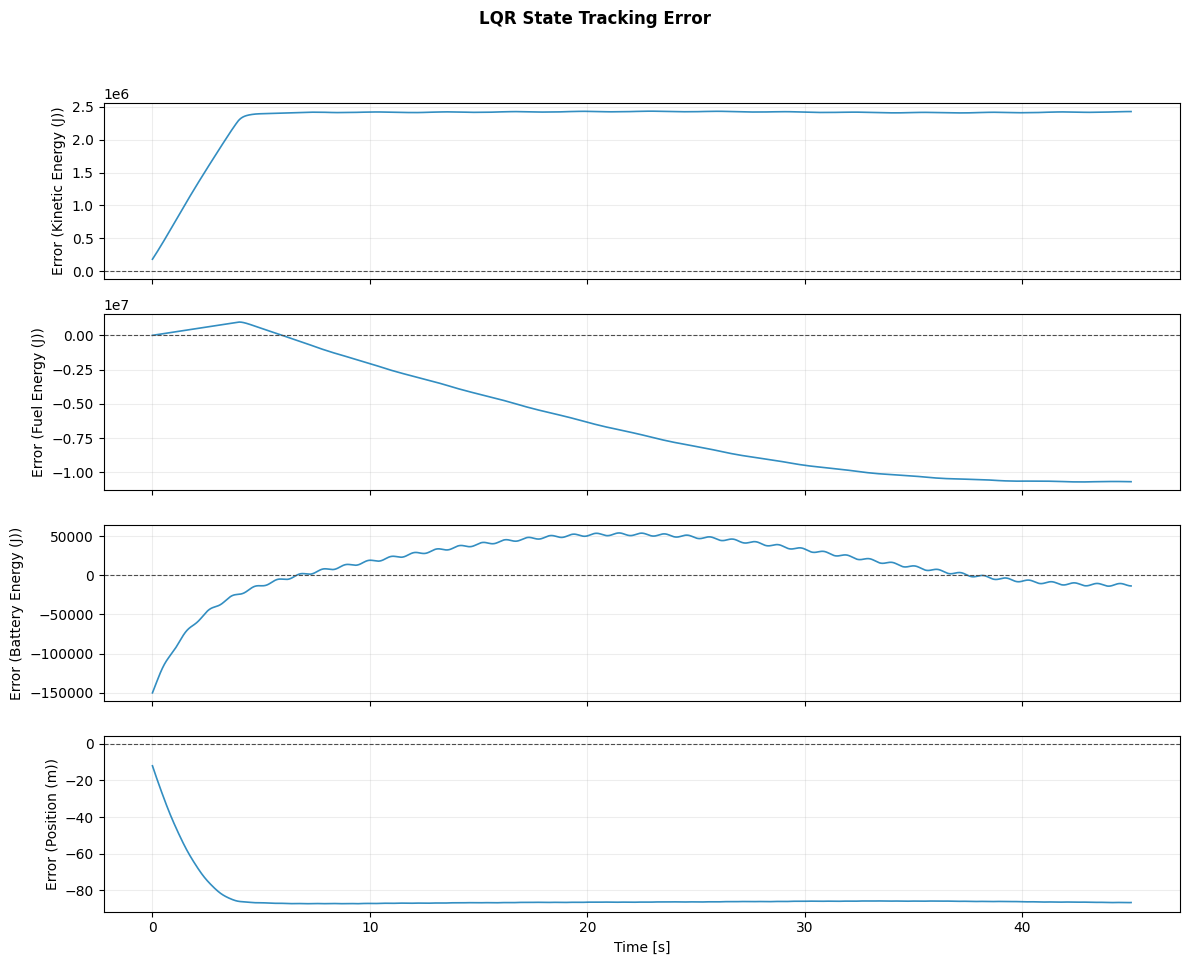

In [ ]:
t = lqr_result['t']
x = lqr_result['x']
x_ref = lqr_result['x_ref']

error = x - x_ref

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

state_labels = ['Kinetic Energy (J)', 'Fuel Energy (J)', 'Battery Energy (J)', 'Position (m)']

for i in range(4):
    axes[i].plot(t, error[i, :], color=_CLR['lqr'], lw=_LW, alpha=_ALPHA)
    axes[i].axhline(0, color='0.3', lw=0.8, linestyle='--')
    axes[i].set_ylabel(f'Error ({state_labels[i]})')
    axes[i].grid(True, alpha=0.22)

axes[-1].set_xlabel('Time [s]')
fig.suptitle('LQR State Tracking Error', fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
_save(fig, out / 'lqr_state_tracking_error.png')
plt.show()

### LQR Control Magnitudes

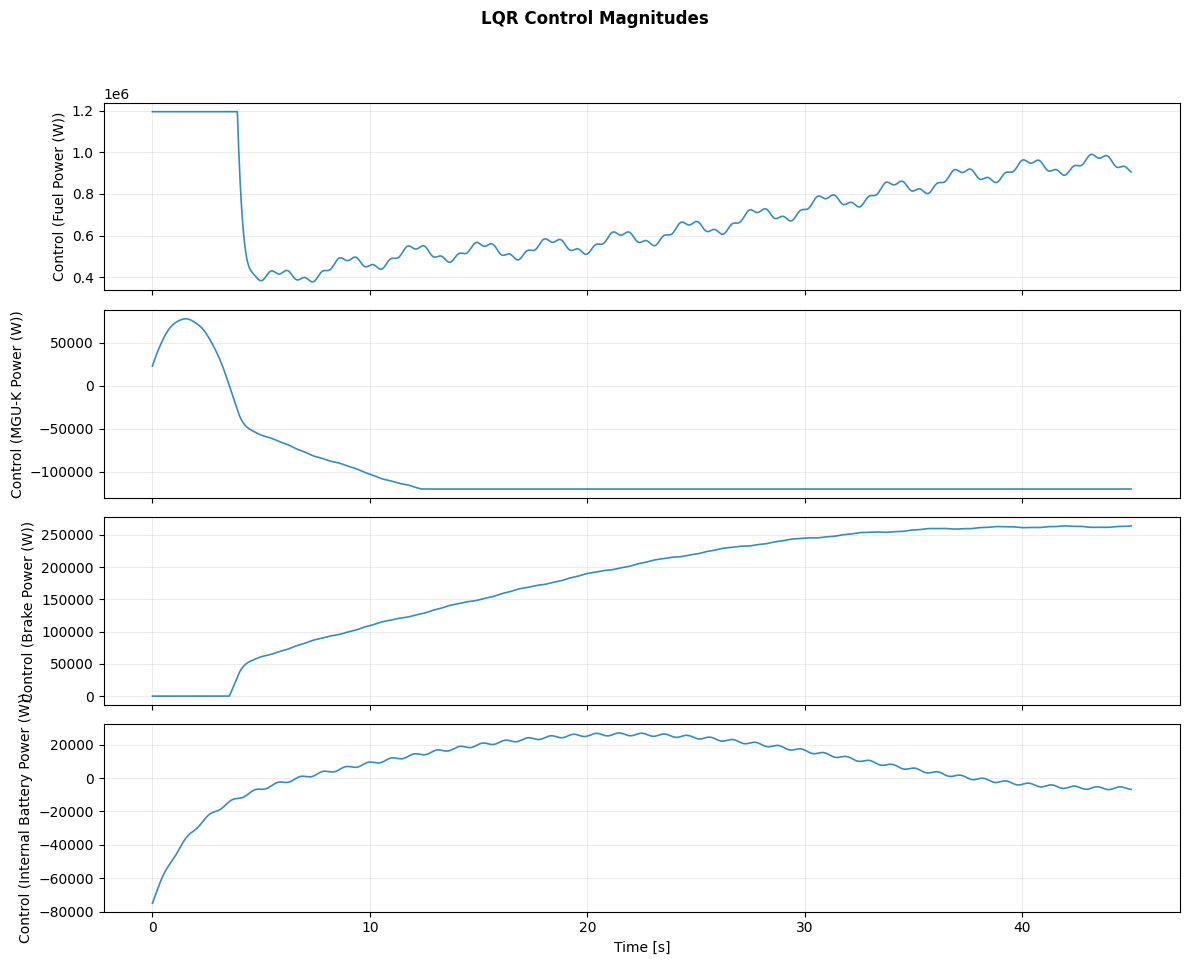

In [ ]:
t = lqr_result['t']
u = lqr_result['u']

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

control_labels = ['Fuel Power (W)', 'MGU-K Power (W)', 'Brake Power (W)', 'Internal Battery Power (W)']

for i in range(4):
    axes[i].plot(t, u[i, :], color=_CLR['lqr'], lw=_LW, alpha=_ALPHA)
    axes[i].set_ylabel(f'Control ({control_labels[i]})')
    axes[i].grid(True, alpha=0.22)

axes[-1].set_xlabel('Time [s]')
fig.suptitle('LQR Control Magnitudes', fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
_save(fig, out / 'lqr_control_magnitudes.png')
plt.show()

### RMSE Values

In [ ]:
print("Root Mean Squared Error (RMSE) for each state:")
for k, v in lqr_result['rmse'].items():
    print(f"{k}: {v:.4f}")

Root Mean Squared Error (RMSE) for each state:
E_k_J: 2347034.3617
E_f_J: 7410953.1375
E_b_J: 37974.3389
s_m: 84.8213
